# Diabetes Prediction using Logistic Regression
### Pima Indians Diabetes Dataset
##reference link : https://www.kaggle.com/datasets/jamaltariqcheema/pima-indians-diabetes-dataset

**Name:** Mayank L Surana  
**Date:** 04 October 2026   
**Batch:** A

##Import Libraries

In [39]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import (accuracy_score, precision_score, recall_score, f1_score,
                             roc_auc_score, confusion_matrix, ConfusionMatrixDisplay,
                             RocCurveDisplay, classification_report)

sns.set_style("whitegrid")

##Loading the Dataset

In [40]:
df = pd.read_csv('/content/diabetes.csv')

df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72.0,35,169.5,33.6,0.627,50,1
1,1,85,66.0,29,102.5,26.6,0.351,31,0
2,8,183,64.0,32,169.5,23.3,0.672,32,1
3,1,89,66.0,23,94.0,28.1,0.167,21,0
4,0,137,40.0,35,168.0,43.1,2.288,33,1


##Dataset Shape

In [41]:
print("Number of rows:", df.shape[0])
print("Number of columns:", df.shape[1])

Number of rows: 768
Number of columns: 9


##Listing out all the Column Names

In [42]:
print(df.columns.tolist(), sep='\n')

['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin', 'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome']


##Information regarding the Dataset

In [43]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    float64
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    float64
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(4), int64(5)
memory usage: 54.1 KB


##Statistical Summary

In [44]:
df.describe()  #Gives is the mean,count, Min.. etc,..

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
count,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000,768.000000
mean,3.845052,121.677083,72.389323,29.089844,141.753906,32.434635,0.471876,33.240885,0.348958
std,3.369578,30.464161,12.106039,8.890820,89.100847,6.880498,0.331329,11.760232,0.476951
min,0.000000,44.000000,24.000000,7.000000,14.000000,18.200000,0.078000,21.000000,0.000000
25%,1.000000,99.750000,64.000000,25.000000,102.500000,27.500000,0.243750,24.000000,0.000000
50%,3.000000,117.000000,72.000000,28.000000,102.500000,32.050000,0.372500,29.000000,0.000000
75%,6.000000,140.250000,80.000000,32.000000,169.500000,36.600000,0.626250,41.000000,1.000000
max,17.000000,199.000000,122.000000,99.000000,846.000000,67.100000,2.420000,81.000000,1.000000


##Check Missing Values

In [45]:
df.isnull().sum()

,0
Pregnancies,0
Glucose,0
BloodPressure,0
SkinThickness,0
Insulin,0
BMI,0
DiabetesPedigreeFunction,0
Age,0
Outcome,0


##Identifying & replacing Invalid Zeroes

In [46]:
cols_with_invalid_zeros = ["Glucose", "BloodPressure", "SkinThickness", "Insulin", "BMI"]  #Here e have excluded pregnancies because it may have 0 value
print("Zeros BEFORE replacement:")
print((df[cols_with_invalid_zeros] == 0).sum())
df[cols_with_invalid_zeros] = df[cols_with_invalid_zeros].replace(0, np.nan)
print("\nMissing values AFTER replacement:")
print(df.isnull().sum())

Zeros BEFORE replacement:
Glucose          0
BloodPressure    0
SkinThickness    0
Insulin          0
BMI              0
dtype: int64

Missing values AFTER replacement:
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


#Exploratory visuals (the graphs the checklist wants visible)

## Class distribution

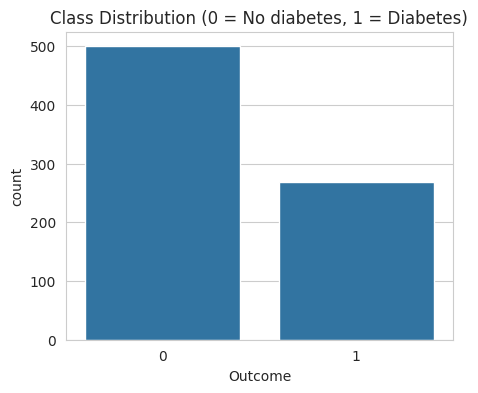

In [47]:
plt.figure(figsize=(5, 4))
sns.countplot(x="Outcome", data=df)
plt.title("Class Distribution (0 = No diabetes, 1 = Diabetes)")
plt.show()


##Feature Distribution

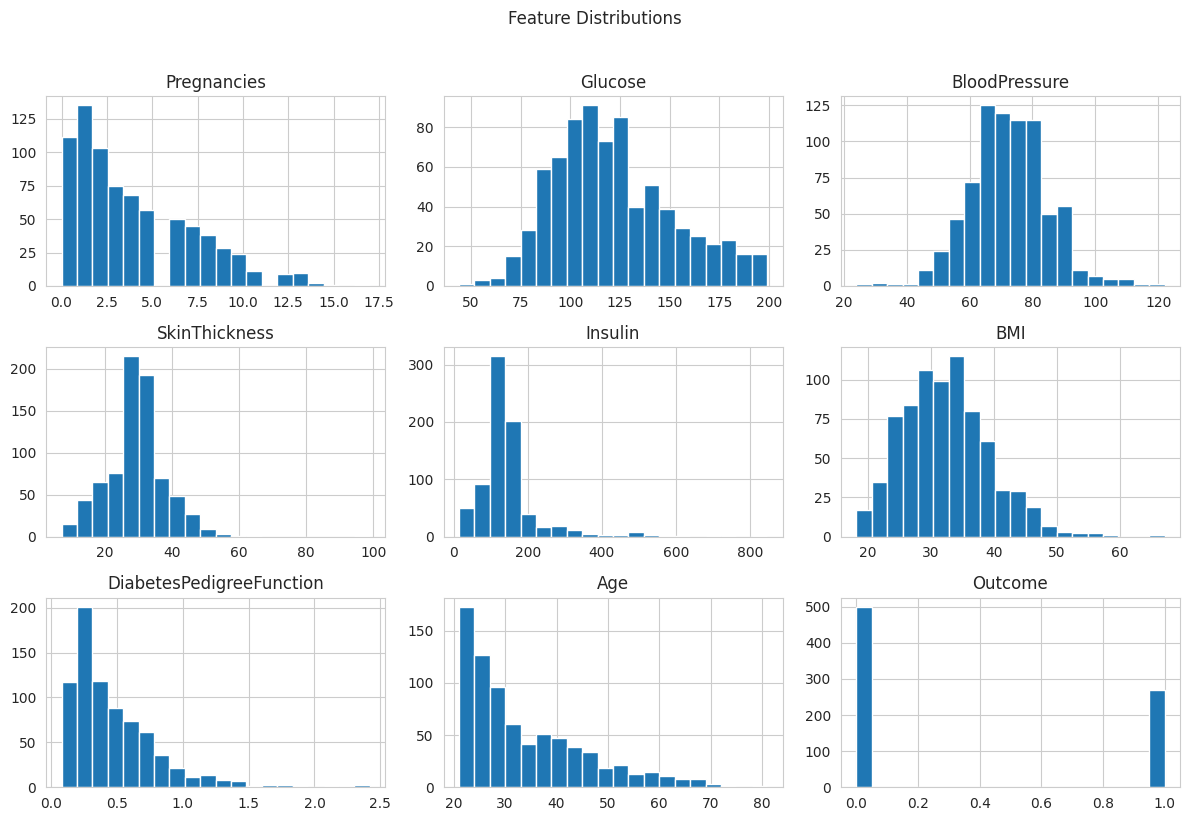

In [58]:
df.hist(figsize=(12, 8), bins=20)
plt.suptitle("Feature Distributions", y=1.02)
plt.tight_layout()
plt.show()


##Co relation Heatmap

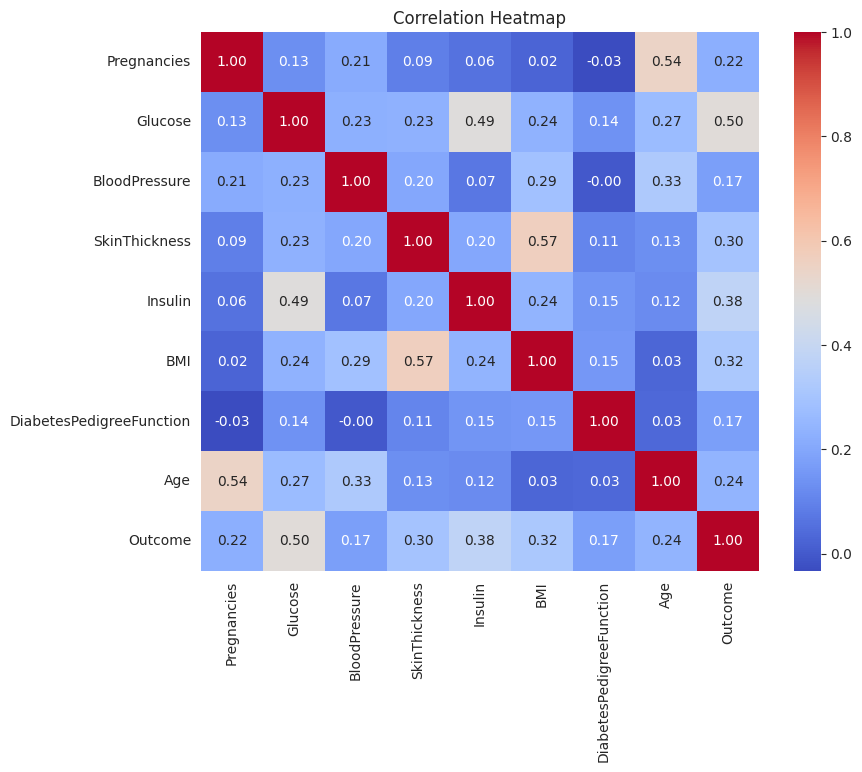

In [49]:
# Correlation heatmap
plt.figure(figsize=(9, 7))
sns.heatmap(df.corr(), annot=True, fmt=".2f", cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

##Train-test split

In [50]:
X = df.drop("Outcome", axis=1)  #The column Outcome is dropped
y = df["Outcome"] #This is what we are predicting

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)  #Certain amount or let us say - Small part pf the dataset is taken from the training dataset to test

print("Train:", X_train.shape, "| Test:", X_test.shape)

Train: (614, 8) | Test: (154, 8)


##Building and training the model

In [51]:
model = Pipeline(steps=[
    ("imputer", SimpleImputer(strategy="median")),   #Fills the coulumn's NAN value with its Median
    ("scaler", StandardScaler()),   #(value − mean) / standard deviation
    ("logreg", LogisticRegression(class_weight="balanced", max_iter=1000, random_state=42))
])

model.fit(X_train, y_train)
print("Model trained successfully")

Model trained successfully


##Evaluating the accuracy, precision

In [59]:
y_pred = model.predict(X_test)   #0.5 is cut off
y_prob = model.predict_proba(X_test)[:, 1]

metrics = pd.DataFrame({
    "Metric": ["Accuracy", "Precision", "Recall", "F1-score", "ROC-AUC"],
    "Result": [accuracy_score(y_test, y_pred),    #Overall correct predictions
               precision_score(y_test, y_pred),   #Reliability of positive predictions
               recall_score(y_test, y_pred),      #Actual positive cases detected
               f1_score(y_test, y_pred),          #Balance of precision and recall
               roc_auc_score(y_test, y_prob)],    #Overall class-separation ability"
  })
metrics["Result"] = metrics["Result"].round(3)
display(metrics)
print(classification_report(y_test, y_pred, target_names=["No diabetes", "Diabetes"]))

,Metric,Result
0,Accuracy,0.747
1,Precision,0.609
2,Recall,0.778
3,F1-score,0.683
4,ROC-AUC,0.827


              precision    recall  f1-score   support

 No diabetes       0.86      0.73      0.79       100
    Diabetes       0.61      0.78      0.68        54

    accuracy                           0.75       154
   macro avg       0.73      0.75      0.74       154
weighted avg       0.77      0.75      0.75       154



##Confusion matrix and ROC curve

###**Description :** A confusion matrix is a table used to evaluate the performance of a classification model by comparing its predicted outcomes against the actual ground-truth values

TN = 73 | FP = 27 | FN = 12 | TP = 42


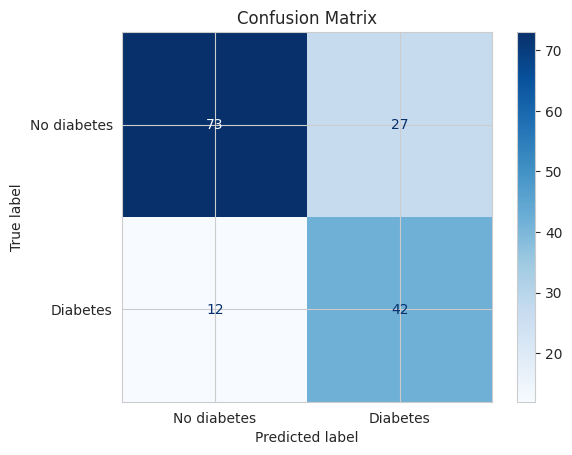

In [60]:
cm = confusion_matrix(y_test, y_pred)
tn, fp, fn, tp = cm.ravel()

# • tn (True Negatives): Top-left element. Actual negative classes correctly predicted as negative.
# • fp (False Positives): Top-right element. Actual negative classes incorrectly predicted as positive.
# • fn (False Negatives): Bottom-left element. Actual positive classes incorrectly predicted as negative.
# • tp (True Positives): Bottom-right element. Actual positive classes correctly predicted as positive.

print(f"TN = {tn} | FP = {fp} | FN = {fn} | TP = {tp}")

ConfusionMatrixDisplay(cm, display_labels=["No diabetes", "Diabetes"]).plot(cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


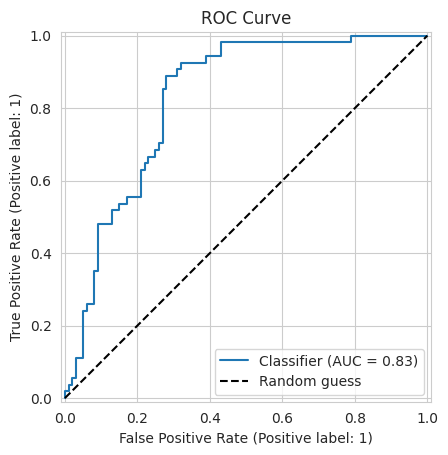

In [55]:
RocCurveDisplay.from_predictions(y_test, y_prob)
plt.plot([0, 1], [0, 1], "k--", label="Random guess")
plt.title("ROC Curve")
plt.legend()
plt.show()

##Interpreting their coefficients

,Feature,Coefficient,Odds Ratio
1,Glucose,0.904,2.470
4,Insulin,0.849,2.337
5,BMI,0.474,1.606
0,Pregnancies,0.319,1.375
3,SkinThickness,0.278,1.320
6,DiabetesPedigreeFunction,0.228,1.256
7,Age,0.164,1.179
2,BloodPressure,0.024,1.024


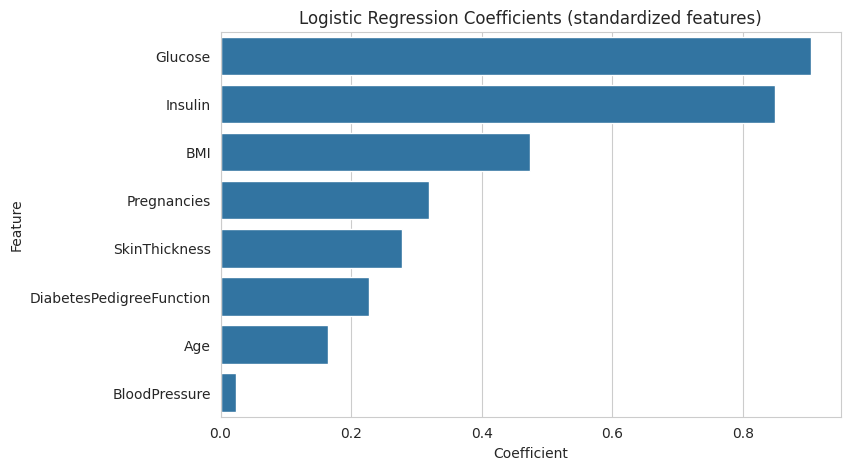

In [56]:
coef_df = pd.DataFrame({
    "Feature": X.columns,
    "Coefficient": model.named_steps["logreg"].coef_[0]
})
coef_df["Odds Ratio"] = np.exp(coef_df["Coefficient"])
coef_df = coef_df.sort_values("Coefficient", ascending=False)
display(coef_df.round(3))

plt.figure(figsize=(8, 5))
sns.barplot(x="Coefficient", y="Feature", data=coef_df)
plt.title("Logistic Regression Coefficients (standardized features)")
plt.show()